<a href="https://colab.research.google.com/github/aryasaidwork03-byte/data-analytics-portfolio/blob/main/Super%20Store%20Analytic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Library & Data

In [ ]:
# Load Library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load Data
data = pd.read_csv("/content/drive/MyDrive/Portofolio/Portfolio/Superstore.csv", encoding='ISO-8859-1')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# Data Prep


In [ ]:
# Duplication check
x = data.groupby(["Customer ID","Customer Name","City"],as_index=False).agg(Sales =("Sales","sum"))
x[x.duplicated(subset=["Customer Name","City"],keep=False)] # no duplication

# Formating Data
data["Order Date"] = pd.to_datetime(data["Order Date"],dayfirst=True) # Convert object to datetime
data["Ship Date"] = pd.to_datetime(data["Ship Date"],dayfirst=True) # Convert object to datetime

# Data Manipulation
data["Order Year"] = data["Order Date"].dt.year # Year of order
data["Order Month"] = data["Order Date"].dt.month # Month of order
data["Order Date_a"] = (
    data["Order Date"]
      .dt.to_period("M")
      .dt.to_timestamp(how="end")
      .dt.normalize()
) # convert to last date of month
data["Shipping Year"] = data["Ship Date"].dt.year # Year of Shipping
data["Shipping Month"] = data["Ship Date"].dt.month # Month of shipping
data["Ship Date_a"] = (
    data["Ship Date"]
      .dt.to_period("M")
      .dt.to_timestamp(how="end")
      .dt.normalize()
) # convert to last date of month
# Data Retention
# Data binning
def support(x):
  if x > 1:
    return "Retention"
  else:
    return "First"
# data_retentionm
data_retentionm = (data.groupby(["Customer ID","Order Year","Order Date_a","Order Month","Segment"],as_index=False)
                        .agg(Sales = ("Sales","sum"))
                        )
data_cohortm = (data.groupby(["Customer ID","Order Year"],as_index=False)
                        .agg(Cohort_Month = ("Order Month","min"))
                      ) # Month
data_retentionm = data_retentionm.merge(data_cohortm,on=["Customer ID","Order Year"], how="left")
data_retentionm["period_numm"] = (data_retentionm["Order Month"]-data_retentionm["Cohort_Month"])+1
data_retentionm["support_m"] = data_retentionm["period_numm"].apply(support)
# data_retentiony
data_retentiony = (data.groupby(["Customer ID","Order Year","Segment"],as_index=False)
                        .agg(Sales = ("Sales","sum"))
                        )
data_cohorty = (data.groupby("Customer ID",as_index=False)
                        .agg(Cohort_Year = ("Order Year","min"))
                      ) # Month
data_retentiony = data_retentiony.merge(data_cohorty,on=["Customer ID"], how="left")
data_retentiony["period_numm"] = (data_retentiony["Order Year"]-data_retentiony["Cohort_Year"])+1
data_retentiony["support_m"] = data_retentiony["period_numm"].apply(support)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country         9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9994 non-null   int64         
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

# Visualisation

## Sales and Profit Performance

In [ ]:
# Sales group by order year
x = (data.groupby("Order Year", as_index=False)
     .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), QTY=("Quantity","sum"))
     .sort_values("Order Year")
     .assign(
         Sales_Growth = lambda d: d['Sales'].pct_change() * 100,
         Profit_Growth = lambda d: d['Profit'].pct_change() * 100,
         QTY_Growth = lambda d: d['QTY'].pct_change() * 100
     )
     .fillna(0)
    )

# formating growth to percentage
x['Sales_Growth'] = x['Sales_Growth'].map('{:.2f}%'.format)
x['Profit_Growth'] = x['Profit_Growth'].map('{:.2f}%'.format)
x['QTY_Growth'] = x['QTY_Growth'].map('{:.2f}%'.format)
x

,Order Year,Sales,Profit,QTY,Sales_Growth,Profit_Growth,QTY_Growth
0,2011,484247.4981,49543.9741,7581,0.00%,0.00%,0.00%
1,2012,470532.5090,61618.6037,7979,-2.83%,24.37%,5.25%
2,2013,608473.8300,81726.9308,9810,29.32%,32.63%,22.95%
3,2014,733947.0232,93507.5131,12503,20.62%,14.41%,27.45%


## Discount Evaluation

In [ ]:
data14 = data[data["Order Year"]==2014]
data14["label1"] = np.where(data14["Profit"] < 0, "Deficit", "Surplus")
x = data14.groupby("Discount",as_index=False).agg(Sales=("Sales","sum"),Profit=("Profit","sum"),Volume=("Quantity","sum"))
x.sort_values(by="Volume",ascending=False)

/tmp/ipykernel_21119/2775025715.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data14["label1"] = np.where(data14["Profit"] < 0, "Deficit", "Surplus")


,Discount,Sales,Profit,Volume
0,0.00,348821.7900,104159.3502,6050
3,0.20,250043.0960,33079.9369,4505
10,0.70,12057.4950,-12070.7511,541
11,0.80,7829.7500,-13244.4638,472
6,0.40,34100.0520,-7833.1461,277
4,0.30,31306.8980,-3867.6022,259
9,0.60,2039.6320,-1968.8777,118
1,0.10,18957.3480,3300.5929,98
2,0.15,8762.7945,537.5329,71
8,0.50,13801.4450,-6864.3883,64


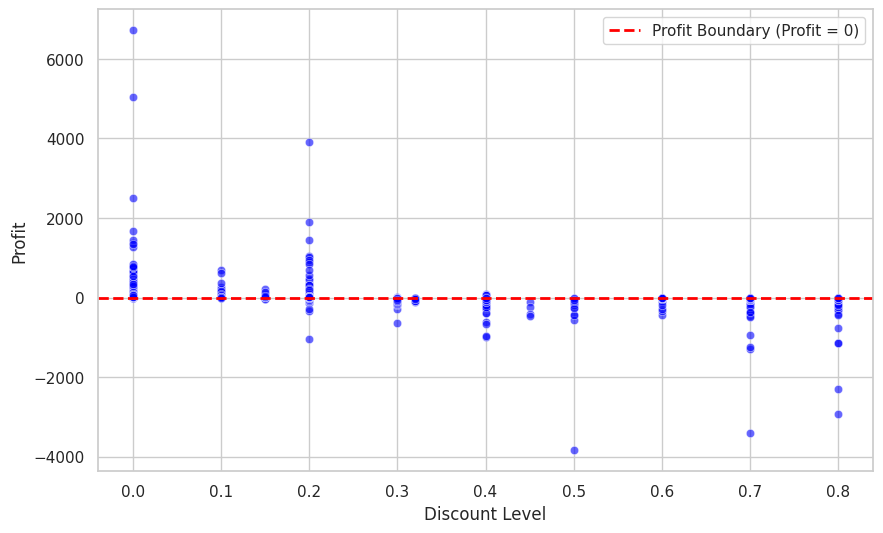

In [ ]:
# 1. Data Slicing: Filter data for the year 2014
data14 = data[data["Order Year"] == 2014]

# 2. Set figure size and theme for a professional look
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create a Scatter Plot
# X-axis = Discount, Y-axis = Profit
# Note: Changed data=df to data=data14 to apply the filter
scatter = sns.scatterplot(
    data=data14,
    x='Discount',
    y='Profit',
    alpha=0.6, # Make points slightly transparent to see overlapping data
    color='blue'
)

# 4. Add a Zero Line (Profit/Loss Boundary)
# This is crucial to highlight which transactions result in a LOSS
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Profit Boundary (Profit = 0)')

# 5. Add Title and Labels
plt.xlabel('Discount Level', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.legend()

# 6. Display the plot
plt.show()

## Product Performance

In [ ]:
# year of 2014 by segment
# Sales & Profit by categiry
x = data[data["Order Year"]==2014].copy()
x1 = (x.groupby("Sub-Category", as_index=False)
     .agg(Total_Profit=("Profit", "sum"))
     .sort_values("Total_Profit")
    )

# Sales by Sub-Category and segment
x2 = x.pivot_table(index = "Sub-Category",
                        columns = "Segment",
                        values = "Profit",
                        aggfunc="sum").reset_index()
y = pd.merge(x2,x1,on="Sub-Category",how="left")
y.sort_values(by="Total_Profit",ascending=False)

,Sub-Category,Consumer,Corporate,Home Office,Total_Profit
6,Copiers,13416.9330,3362.9396,8251.9176,25031.7902
0,Accessories,5764.6607,5920.5599,3987.1364,15672.3570
13,Phones,6478.0960,2672.0495,3721.8577,12872.0032
12,Paper,5367.8744,3475.1306,3206.0564,12049.0614
1,Appliances,3443.2847,3928.9470,493.0366,7865.2683
3,Binders,5003.6203,2981.9875,-248.5127,7737.0951
5,Chairs,3199.9618,3557.8014,885.7861,7643.5493
14,Storage,1565.6042,3912.4753,1889.5060,7367.5855
9,Furnishings,2163.2179,989.1214,946.8235,4099.1628
2,Art,1225.3020,621.0255,380.8448,2227.1723


## Customer Segmentation

### Composition

In [ ]:
x = data[data["Order Year"]==2014]
x.groupby("Segment",as_index=False).agg(Revenue=("Sales","sum"))

,Segment,Revenue
0,Consumer,332473.0599
1,Corporate,242011.2324
2,Home Office,159462.7309


### Consumer Top Sub-Category

In [ ]:
x = data[(data["Order Year"]==2014)&(data["Segment"]=="Consumer")]
x.groupby("Sub-Category",as_index=False).agg(Revenue=("Sales","sum"),qty=("Quantity","sum")).sort_values(by="Revenue",ascending=False)

,Sub-Category,Revenue,qty
13,Phones,51825.3540,541
5,Chairs,50616.9810,333
3,Binders,37447.3510,979
6,Copiers,29919.7980,24
16,Tables,27675.6720,163
14,Storage,23490.3280,458
0,Accessories,22946.4640,548
1,Appliances,21881.0500,375
4,Bookcases,18305.6289,160
9,Furnishings,13619.2460,563


### Corporate Top Sub-Category

In [ ]:
x = data[(data["Order Year"]==2014)&(data["Segment"]=="Corporate")]
x.groupby("Sub-Category",as_index=False).agg(Revenue=("Sales","sum"),qty=("Quantity","sum")).sort_values(by="Revenue",ascending=False)

,Sub-Category,Revenue,qty
14,Storage,29231.7220,324
5,Chairs,28368.4410,207
11,Machines,27819.3290,45
13,Phones,26704.4360,311
3,Binders,25544.8630,653
0,Accessories,24121.3700,354
1,Appliances,18249.6280,214
16,Tables,15766.9840,113
6,Copiers,9899.8200,22
4,Bookcases,8551.4374,96


### Home Office Top Sub-Category

In [ ]:
x = data[(data["Order Year"]==2014)&(data["Segment"]=="Home Office")]
x.groupby("Sub-Category",as_index=False).agg(Revenue=("Sales","sum"),qty=("Quantity","sum")).sort_values(by="Revenue",ascending=False)

,Sub-Category,Revenue,qty
13,Phones,27113.1020,241
6,Copiers,23079.7700,27
16,Tables,17450.8865,114
14,Storage,17112.0800,244
5,Chairs,16568.9310,134
0,Accessories,12878.3980,177
11,Machines,11947.6690,45
3,Binders,9993.9750,445
9,Furnishings,7285.6260,207
12,Paper,7025.7060,312


## Customer Retention

# Store to BigQuery

In [ ]:
from google.cloud import bigquery
from google.oauth2 import service_account
from google.api_core.exceptions import NotFound
import pandas as pd

SERVICE_ACCOUNT_PATH = (
    "/content/drive/MyDrive/Portofolio/Superstore/super-store-data-analytics-ea84e3fdb453.json"
)

credentials = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_PATH
)

client = bigquery.Client(
    credentials=credentials,
    project=credentials.project_id
)
# Tabel
tables = {
    "Transaction": data,
    "Retention per Year": data_retentiony,
    "Retention per Month": data_retentionm
}
dataset_id = "my_new_dataset"
project_id = client.project
full_dataset_id = f"{project_id}.{dataset_id}"

# Pastikan dataset ada
try:
    client.get_dataset(full_dataset_id)
    print(f"📁 Dataset '{dataset_id}' Already Exist.")
except NotFound:
    dataset = bigquery.Dataset(full_dataset_id)
    dataset.location = "US"  # PALING AMAN UNTUK POWER BI
    client.create_dataset(dataset)
    print(f"📁 Dataset '{dataset_id}' Created.")

# Upload tabel
for table_name, df in tables.items():

    if df.empty:
        print(f"⚠ Tabel '{table_name}' pass (Empty DataFrame).")
        continue

    # Rapikan kolom tanggal
    for col in df.columns:
        if "tgl" in col.lower() or "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")

    table_id = f"{full_dataset_id}.{table_name}"

    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",
        autodetect=True
    )

    client.load_table_from_dataframe(
        df,
        table_id,
        job_config=job_config
    ).result()

    print(f"✔ Tabel '{table_name}' Update Successfully.")

📁 Dataset 'my_new_dataset' Already Exist.
✔ Tabel 'Transaction' Update Successfully.
✔ Tabel 'Retention per Year' Update Successfully.
✔ Tabel 'Retention per Month' Update Successfully.
